In [ ]:
#%matplotlib ipympl
import math
import torch as tn
import torchtt as tntt
import numpy as np
from src.qtt_interpolation.utils import *
import matplotlib.pyplot as plt

c:\Users\mel_s\miniconda3\Lib\site-packages\torchtt\_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\mel_s\miniconda3\Lib\site-packages\torchtt\_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\mel_s\miniconda3\Lib\site-packages\torchtt\solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\mel_s\miniconda3\Lib\site-packages\torchtt\cpp.py:12: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\mel_s\miniconda3\Lib\site-packages\torchtt\__init__.py:34: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(


In [ ]:
depth = 14
H = 0.5
w = 2**(-H)
eps=1e-8
levels = []
r = 10
var=1
octaves = 10
amp=2
for i in range(1,octaves+1):
    phi1 = tntt.TT(qtt_polynomial_cores([1,-1], depth-i))
    phi2 = tntt.TT(qtt_polynomial_cores([0,1], depth-i))
    # define shift matrix
    sm = P_qtt( 2**i -1, i)

    if i == 1:
        noise = tntt.TT(tn.rand(2, dtype=tn.float64))
        M = tntt.TT(tn.tensor([[0,1],[1,0]],dtype=tn.float64),[(2,2)])
        mpsm = tntt.kron(noise,phi1) + tntt.kron( (M@noise).round(), phi2)
        mpsm = mpsm.round(eps)
        levels.append(mpsm)
    else:
        delta = tntt.kron(tntt.ones([2]*(i-1)),tntt.TT(tn.tensor([0,1])) )
        noise = tntt.randn([2]*i,[1]+[r]*(i-1)+[1],var=var)
        noise = amp*noise*delta
        level = tntt.kron(noise,phi1) + tntt.kron( (sm@noise).round(), phi2)
        mpsm += w**(i-1) * level
        mpsm = (mpsm).round(eps)
        levels.append(mpsm)

In [ ]:
def mid_point_1d(ncores, H,octaves=None, nrank=10,var=1,eps=1e-10):

    if octaves==None:
        octaves = ncores
    depth = ncores
    H = 0.7
    w = 2**(-H)
    r = nrank

    for i in range(1,octaves+1):
        phi1 = tntt.TT(qtt_polynomial_cores([1,-1], depth-i))
        phi2 = tntt.TT(qtt_polynomial_cores([0,1], depth-i))
        # define shift matrix
        sm = P_qtt( 2**i -1, i)
        if i == 1:
            noise = tntt.TT(tn.rand(2, dtype=tn.float64))
            M = tntt.TT(tn.tensor([[0,1],[1,0]],dtype=tn.float64),[(2,2)])
            mpsm = tntt.kron(noise,phi1) + tntt.kron( (M@noise).round(), phi2)
            mpsm = mpsm.round(eps)
        else:
            delta = tntt.kron(tntt.ones([2]*(i-1)),tntt.TT(tn.tensor([0,1])) )
            noise = tntt.randn([2]*i,[1]+[r]*(i-1)+[1],var=var)
            noise = noise*delta
            level = tntt.kron(noise,phi1) + tntt.kron( (sm@noise).round(), phi2)
            mpsm += w**(i-1) * level
            mpsm = (mpsm).round(eps)

    return mpsm

In [ ]:
mpsm

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, 27, 17, 9, 5, 3, 2, 2, 2, 2, 1]

Device: cpu, dtype: torch.float64
#entries 2588 compression 0.157958984375

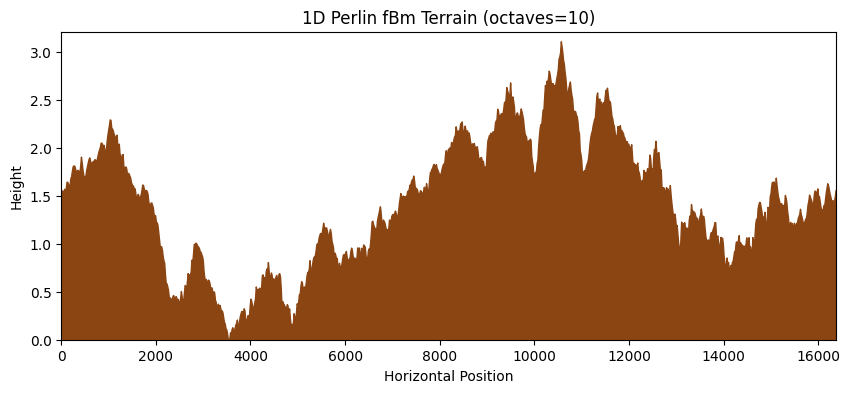

In [ ]:
terrain_heights = mpsm.full().flatten()
terrain_heights -= terrain_heights.min()
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(2**depth)
ax.fill_between(x, terrain_heights, color='saddlebrown')
ax.set_ylim(0, terrain_heights.max()+.1)
ax.set_xlim(0, 2**depth -1)
ax.set_title(f"1D Perlin fBm Terrain (octaves={octaves})")
ax.set_xlabel("Horizontal Position")
ax.set_ylabel("Height")
plt.show()

In [1]:
ncores = 12
H = 0.5
octaves = 10
# ─── Generate circle + independent X/Y noise offsets with octaves ───────────────
num_points = 2**ncores
radius     = 1.0

# Jitter amplitude for X and Y
amplitude_x = 0.05
amplitude_y = 0.05



angles = np.linspace(0, 2 * math.pi, num_points, endpoint=False)
x_base = radius * np.cos(angles)
y_base = radius * np.sin(angles)

# Sample two independent fBm noise curves:
offsets_x = amplitude_x*mid_point_1d(ncores, H,octaves=octaves).full().flatten().numpy()
offsets_y = amplitude_y*mid_point_1d(ncores, H,octaves=octaves).full().flatten().numpy()
x_noisy = x_base + offsets_x
y_noisy = y_base + offsets_y

# ─── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
# Perfect circle in dashed gray
plt.plot(x_base, y_base, linestyle='--', color='gray', label='Perfect Circle')
# Noisy circle in solid black
plt.plot(x_noisy, y_noisy, color='black', linewidth=1.5, label='Hand‐Drawn Circle (fbm)')

plt.gca().set_aspect('equal', 'box')
plt.axis('off')
plt.title("Circle with Independent fBm (Multi‐Octave Perlin) Offsets")
plt.show()


NameError: name 'np' is not defined

## Sounds

In [1]:
import math
import random
import numpy as np
import scipy.signal as signal
import scipy.io.wavfile as wavfile

# ─── 1D Perlin Noise (single octave) ───────────────────────────────
_perm = list(range(256))
random.seed(0)
random.shuffle(_perm)
_perm += _perm

def fade(t):
    return t * t * t * (t * (t * 6 - 15) + 10)

def lerp(a, b, t):
    return a + t * (b - a)

def grad(hash_val, x):
    return (1 if (hash_val & 1) == 0 else -1) * x

def perlin1d(x):
    x0 = math.floor(x)
    x1 = x0 + 1
    dx0 = x - x0
    dx1 = dx0 - 1.0
    h0 = _perm[x0 & 255]
    h1 = _perm[x1 & 255]
    dot0 = grad(h0, dx0)
    dot1 = grad(h1, dx1)
    u = fade(dx0)
    return lerp(dot0, dot1, u)

# ─── Fractal Brownian Motion wrapper ────────────────────────────────
def fbm1d(x, octaves=6, persistence=0.5, lacunarity=2.0):
    total = 0.0
    amplitude = 1.0
    frequency = 1.0
    max_amp = 0.0
    for _ in range(octaves):
        total += perlin1d(x * frequency) * amplitude
        max_amp += amplitude
        amplitude *= persistence
        frequency *= lacunarity
    return total / max_amp  # normalized to [-1,1]

# ─── Wind Sound Generation ───────────────────────────────────────────
fs = 44100              # sample rate (Hz)
duration = 30.0         # now 30 seconds long
num_samples = int(fs * duration)

# fBm parameters
noise_scale = 20000.0   # controls “speed” of the wind fluctuations
octaves = 6
persistence = 0.5
lacunarity = 2.0

# allocate buffer
wind_raw = np.zeros(num_samples, dtype=np.float32)

# fill with Perlin-fBm samples
for n in range(num_samples):
    wind_raw[n] = fbm1d(n / noise_scale, octaves, persistence, lacunarity)

# ─── Low-pass filter to smooth out high frequencies ────────────────
b, a = signal.butter(4, 3000/(fs/2), btype='low')
wind_filtered = signal.filtfilt(b, a, wind_raw)

# normalize to [-1, +1]
wind_filtered -= wind_filtered.min()
wind_filtered /= wind_filtered.max()
wind_filtered = wind_filtered * 2.0 - 1.0

# convert to 16-bit PCM
wind_int16 = np.int16(wind_filtered * 32767)

# write WAV file
out_path = "./data/perlin_wind_30s.wav"
wavfile.write(out_path, fs, wind_int16)

print(f"30 s wind sound written to: {out_path}")


30 s wind sound written to: ./data/perlin_wind_30s.wav
